In [1]:
import pandas as pd
import numpy as np
import os

# Load data saved by the previous notebook (01_data_loader.ipynb).

path = '/Users/aleksandra/Desktop/data'

prices = pd.read_csv(os.path.join(path, "prices.csv"), index_col="date", parse_dates=True)
log_returns = pd.read_csv(os.path.join(path, "log_returns.csv"), index_col="date", parse_dates=True)

print(f"Prices shape: {prices.shape}")
print(f"Log returns shape: {log_returns.shape}")
print(f"Period: {log_returns.index.min().date()} to {log_returns.index.max().date()}")

log_returns.head()

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

Prices shape: (2036, 6)
Log returns shape: (2035, 6)
Period: 2021-01-02 to 2026-07-29


# 1.Distribution Analysis

In [2]:
from scipy.stats import skew, kurtosis, jarque_bera

def distribution_stats(returns):
    s = skew(returns)
    k = kurtosis(returns, fisher=True)  # excess kurtosis (normal = 0)
    jb_stat, jb_pvalue = jarque_bera(returns)

    return {
        "skewness": s,
        "excess_kurtosis": k,
        "jarque_bera_stat": jb_stat,
        "jarque_bera_pvalue": jb_pvalue,
        "is_normal_5pct": jb_pvalue > 0.05,  # fail to reject normality
    }

dist_results = []
for asset in log_returns.columns:
    returns = log_returns[asset].dropna()
    row = {"asset": asset}
    row.update(distribution_stats(returns))
    dist_results.append(row)

dist_table = pd.DataFrame(dist_results).set_index("asset")
dist_table.to_csv(f"{DATA_DIR}/distribution_stats.csv")

print(dist_table.round(4))

          skewness  excess_kurtosis  jarque_bera_stat  jarque_bera_pvalue  \
asset                                                                       
BTC-USD    -0.1201           4.0495      1.395377e+03                 0.0   
ETH-USD    -0.2056           5.4419      2.525403e+03                 0.0   
BNB-USD     0.8322          24.6294      5.167025e+04                 0.0   
SOL-USD    -0.3594           9.0189      6.940744e+03                 0.0   
XRP-USD     1.2703          17.8825      2.766242e+04                 0.0   
DOGE-USD    6.4518         136.4647      1.593160e+06                 0.0   

          is_normal_5pct  
asset                     
BTC-USD            False  
ETH-USD            False  
BNB-USD            False  
SOL-USD            False  
XRP-USD            False  
DOGE-USD           False  


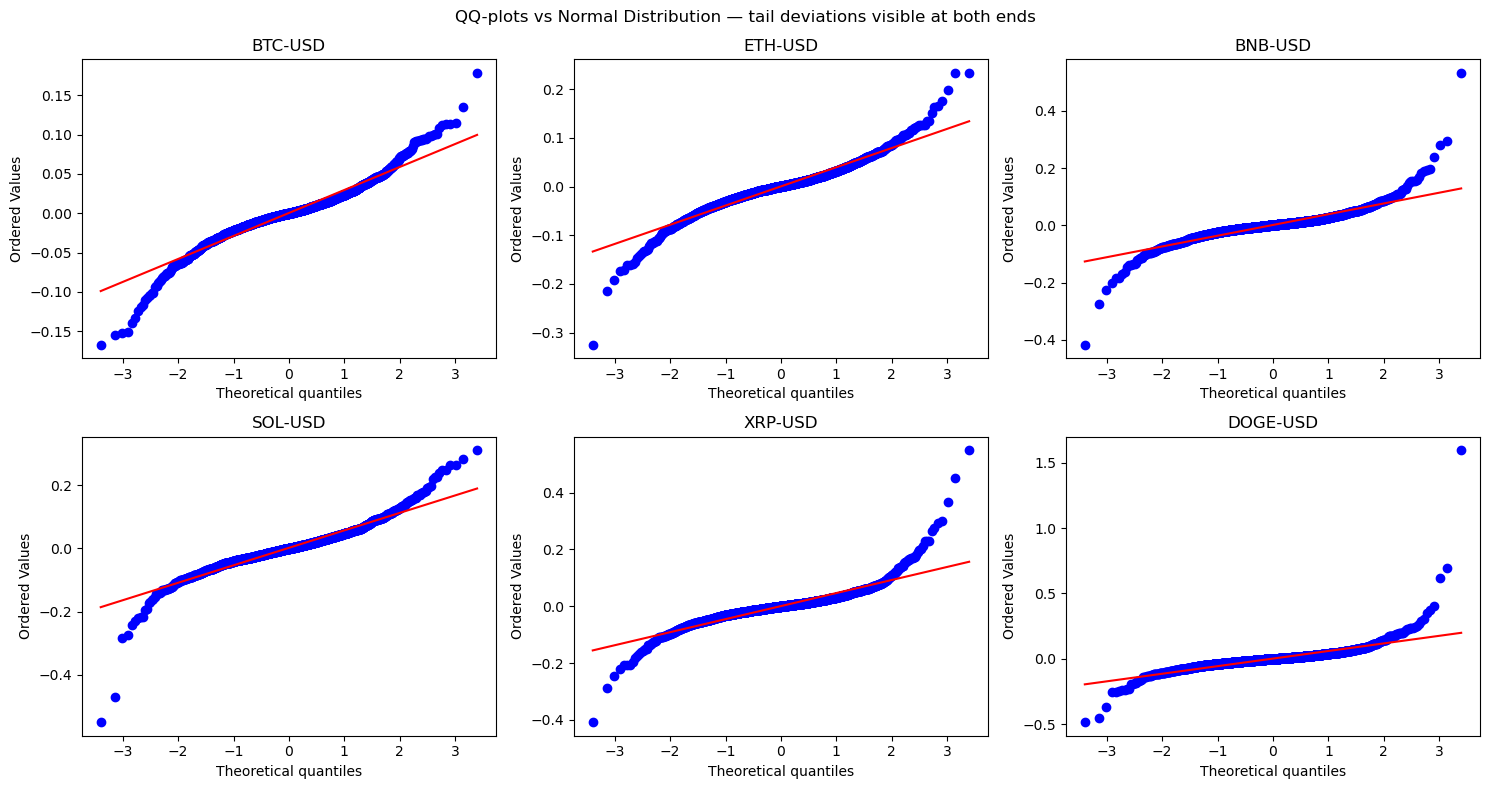

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import probplot

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, asset in enumerate(log_returns.columns):
    probplot(log_returns[asset].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(asset)

plt.suptitle("QQ-plots vs Normal Distribution — tail deviations visible at both ends")
plt.tight_layout()
plt.show()

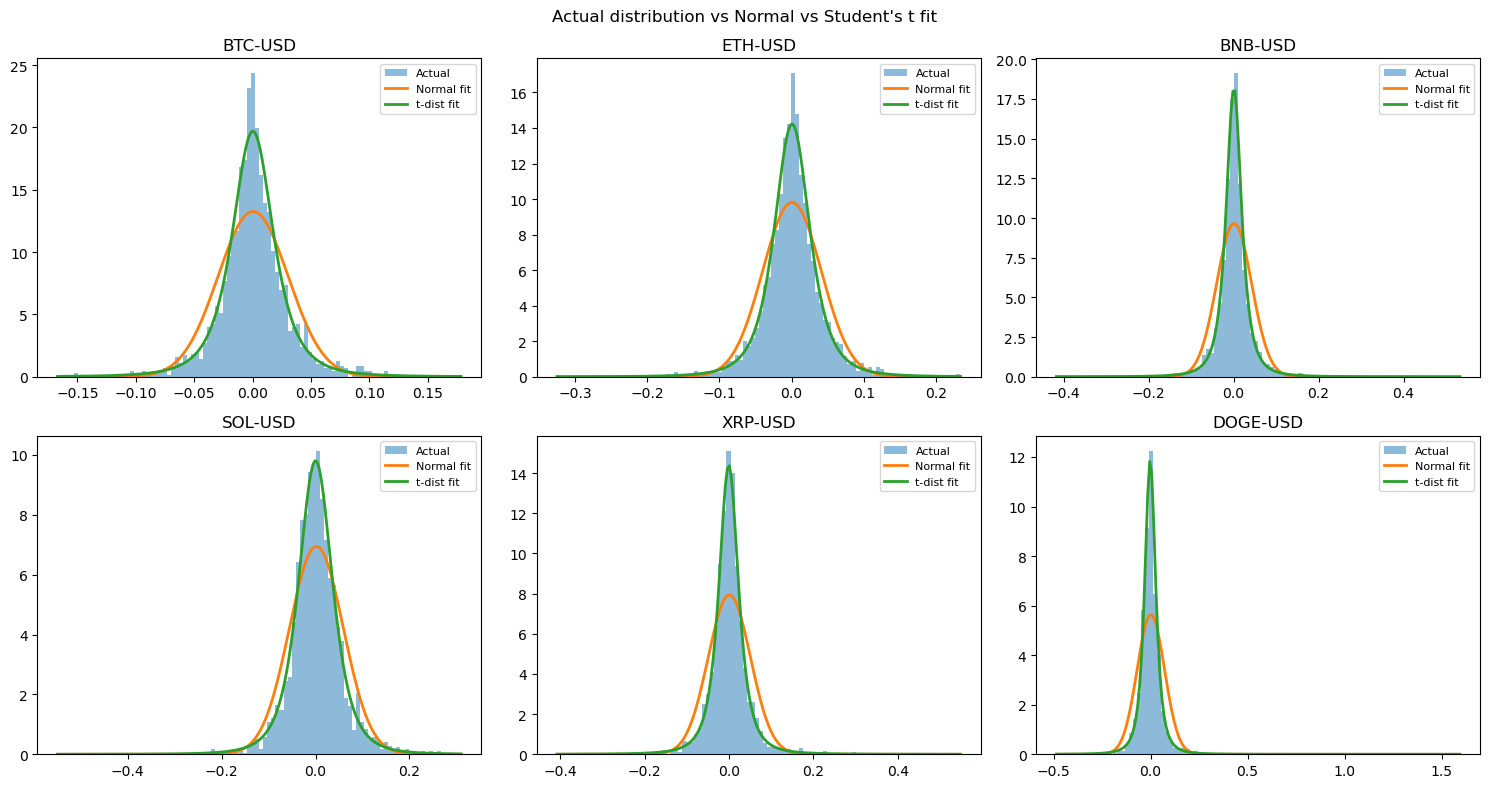

In [4]:
from scipy.stats import norm, t as t_dist

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, asset in enumerate(log_returns.columns):
    returns = log_returns[asset].dropna()
    axes[i].hist(returns, bins=100, density=True, alpha=0.5, label="Actual")

    x = np.linspace(returns.min(), returns.max(), 200)
    axes[i].plot(x, norm.pdf(x, returns.mean(), returns.std()), label="Normal fit", linewidth=2)

    df, loc, scale = t_dist.fit(returns)
    axes[i].plot(x, t_dist.pdf(x, df, loc, scale), label="t-dist fit", linewidth=2)

    axes[i].set_title(asset)
    axes[i].legend(fontsize=8)

plt.suptitle("Actual distribution vs Normal vs Student's t fit")
plt.tight_layout()
plt.show()

# Part 2 Conclusions.
# The Jarque-Bera test rejects normality for **all six assets** (p-value = 0.0 in every case), confirming that none of these return series can be reasonably modeled with a Gaussian distribution.
# Excess kurtosis ranges from 4.05 (BTC) already twice the value expected under normality(0) to an extreme 136.46 (DOGE), indicating a return distribution dominated by rare but massive outliers rather than smoothly decaying tails. BNB (24.63) and XRP (17.88) also show kurtosis an order of magnitude above what a normal distribution would produce, meaning large single-day moves are far more frequent than a Gaussian model would predict.
# Skewness is mixed and asset-specific: BTC, ETH, and SOL are slightly left-skewed (-0.12 to -0.36), consistent with sharper downside crashes than upside rallies, while BNB, XRP, and especially DOGE (6.45) are strongly right-skewed driven by episodic speculative rallies (e.g. meme-coin pumps) rather than symmetric noise.

# Key takeaway for risk manager: the further down the market-cap ladder we go (BTC → DOGE), the worse the normal-distribution assumption becomes. This directly motivates using fat-tailed methods (historical simulation, Student's t Monte Carlo) instead of the variance-covariance (parametric normal) approach suitable for tradfi assets.

# 2. 3 methods VaR (historical, parametric, Monte Carlo)

In [5]:
CONFIDENCE_LEVELS = [0.95, 0.99]

# Historical VaR

In [6]:
def historical_var(returns, confidence=0.95):
    return -np.percentile(returns, (1 - confidence) * 100)

# Parametric VaR (normal distribution)

In [7]:
from scipy.stats import norm

def parametric_var(returns, confidence=0.95):
    mu = returns.mean()
    sigma = returns.std()
    z_score = norm.ppf(1 - confidence)
    return -(mu + z_score * sigma)

# Monte Carlo VaR (t-distribution)

In [8]:
def monte_carlo_var(returns, confidence=0.95, n_simulations=100_000, random_seed=42):
    from scipy.stats import t as t_dist

    # Fit t-distribution to the historical returns
    params = t_dist.fit(returns)
    df, loc, scale = params

    # Simulate many possible daily returns
    rng = np.random.default_rng(random_seed)
    simulated_returns = t_dist.rvs(df, loc=loc, scale=scale, size=n_simulations, random_state=rng)

    return -np.percentile(simulated_returns, (1 - confidence) * 100)

In [9]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

var_results = []

for asset in log_returns.columns:
    returns = log_returns[asset].dropna()
    row = {"asset": asset}
    for cl in CONFIDENCE_LEVELS:
        row[f"historical_var_{int(cl*100)}"] = historical_var(returns, cl)
        row[f"parametric_var_{int(cl*100)}"] = parametric_var(returns, cl)
        row[f"monte_carlo_var_{int(cl*100)}"] = monte_carlo_var(returns, cl)
    var_results.append(row)

var_table = pd.DataFrame(var_results).set_index("asset")
var_table.to_csv(f"{DATA_DIR}/var_results.csv")

print(var_table.round(4))

          historical_var_95  parametric_var_95  monte_carlo_var_95  \
asset                                                                
BTC-USD              0.0470             0.0491              0.0452   
ETH-USD              0.0636             0.0664              0.0607   
BNB-USD              0.0578             0.0666              0.0543   
SOL-USD              0.0819             0.0927              0.0853   
XRP-USD              0.0655             0.0819              0.0678   
DOGE-USD             0.0791             0.1152              0.0837   

          historical_var_99  parametric_var_99  monte_carlo_var_99  
asset                                                               
BTC-USD              0.0858             0.0696              0.0910  
ETH-USD              0.1158             0.0941              0.1172  
BNB-USD              0.1049             0.0947              0.1260  
SOL-USD              0.1389             0.1319              0.1572  
XRP-USD              0.12

# Part 3 Conclusions.

# At the 95% confidence level, parametric (normal) VaR actually looks higher than the other two methods for most assets. This is misleading: it's not that the normal model is "extra safe" — it's that fat tails inflate the historical standard deviation (sigma), and since the normal distribution has only one parameter controlling its shape, that inflated sigma gets spread symmetrically across the entire bell curve, including the "typical day" region we're looking at here. That's why parametric VaR looks conservative at 95% without actually capturing the true shape of the tail.

# At the 99% confidence level — where it matters most for risk management, since we're now deep enough into the tail for fat-tail effects to dominate — the picture flips. Parametric VaR now underestimates risk for 5 out of 6 assets compared to Monte Carlo (t-distribution).

# On average, normal-distribution VaR understates real tail risk by roughly 20% at the 99% level across these five assets. DOGE is the exception — its extreme kurtosis (136.5) inflates parametric sigma enough to push the normal estimate above even historical VaR. But even there, Monte Carlo still shows meaningfully higher risk, confirming the underlying mismatch persists.

# Result: the normal distribution doesn't fail randomly — it fails in a predictable direction that depends on how deep into the tail we look. At 95% it can look overly cautious; at 99%, exactly where risk managers care most, it quietly understates risk. This is why relying on a single VaR method for crypto is risky in itself, and why CVaR — calculated next — matters even more: VaR tells you where the bad scenarios start, CVaR tells you how bad they actually get.

# 3. 3 methods CVaR (historical, parametric, Monte Carlo)

In [10]:
from scipy.stats import norm, t as t_dist

def historical_cvar(returns, confidence=0.95):
    var = historical_var(returns, confidence)
    tail_losses = returns[returns <= -var]
    return -tail_losses.mean()


def parametric_cvar(returns, confidence=0.95):
    mu = returns.mean()
    sigma = returns.std()
    z = norm.ppf(1 - confidence)
    cvar = mu - sigma * norm.pdf(z) / (1 - confidence)
    return -cvar


def monte_carlo_cvar(returns, confidence=0.95, n_simulations=100_000, random_seed=42):
    params = t_dist.fit(returns)
    df, loc, scale = params

    rng = np.random.default_rng(random_seed)
    simulated_returns = t_dist.rvs(df, loc=loc, scale=scale, size=n_simulations, random_state=rng)

    var_threshold = np.percentile(simulated_returns, (1 - confidence) * 100)
    tail_losses = simulated_returns[simulated_returns <= var_threshold]
    return -tail_losses.mean()

In [11]:
cvar_results = []

for asset in log_returns.columns:
    returns = log_returns[asset].dropna()
    row = {"asset": asset}
    for cl in CONFIDENCE_LEVELS:
        row[f"historical_cvar_{int(cl*100)}"] = historical_cvar(returns, cl)
        row[f"parametric_cvar_{int(cl*100)}"] = parametric_cvar(returns, cl)
        row[f"monte_carlo_cvar_{int(cl*100)}"] = monte_carlo_cvar(returns, cl)
    cvar_results.append(row)

cvar_table = pd.DataFrame(cvar_results).set_index("asset")
cvar_table.to_csv(f"{DATA_DIR}/cvar_results.csv")

print(cvar_table.round(4))

          historical_cvar_95  parametric_cvar_95  monte_carlo_cvar_95  \
asset                                                                   
BTC-USD               0.0720              0.0617               0.0762   
ETH-USD               0.0964              0.0834               0.0999   
BNB-USD               0.0922              0.0839               0.1072   
SOL-USD               0.1252              0.1167               0.1330   
XRP-USD               0.1084              0.1029               0.1265   
DOGE-USD              0.1284              0.1448               0.1565   

          historical_cvar_99  parametric_cvar_99  monte_carlo_cvar_99  
asset                                                                  
BTC-USD               0.1157              0.0798               0.1389  
ETH-USD               0.1558              0.1079               0.1791  
BNB-USD               0.1634              0.1087               0.2299  
SOL-USD               0.2194              0.1513       

In [12]:
comparison_table = pd.DataFrame({
    "VaR_95_parametric": var_table["parametric_var_95"],
    "CVaR_95_parametric": cvar_table["parametric_cvar_95"],
    "VaR_95_monte_carlo": var_table["monte_carlo_var_95"],
    "CVaR_95_monte_carlo": cvar_table["monte_carlo_cvar_95"],
    "VaR_99_parametric": var_table["parametric_var_99"],
    "CVaR_99_parametric": cvar_table["parametric_cvar_99"],
    "VaR_99_monte_carlo": var_table["monte_carlo_var_99"],
    "CVaR_99_monte_carlo": cvar_table["monte_carlo_cvar_99"],
})

comparison_table["gap_95_parametric_pct"] = (
    (comparison_table["CVaR_95_parametric"] - comparison_table["VaR_95_parametric"])
    / comparison_table["VaR_95_parametric"] * 100
)
comparison_table["gap_99_parametric_pct"] = (
    (comparison_table["CVaR_99_parametric"] - comparison_table["VaR_99_parametric"])
    / comparison_table["VaR_99_parametric"] * 100
)
comparison_table["gap_99_monte_carlo_pct"] = (
    (comparison_table["CVaR_99_monte_carlo"] - comparison_table["VaR_99_monte_carlo"])
    / comparison_table["VaR_99_monte_carlo"] * 100
)

print(comparison_table[["gap_95_parametric_pct", "gap_99_parametric_pct", "gap_99_monte_carlo_pct"]].round(1))

          gap_95_parametric_pct  gap_99_parametric_pct  gap_99_monte_carlo_pct
asset                                                                         
BTC-USD                    25.6                   14.6                    52.7
ETH-USD                    25.6                   14.6                    52.8
BNB-USD                    25.9                   14.8                    82.5
SOL-USD                    25.9                   14.8                    43.5
XRP-USD                    25.6                   14.7                    71.9
DOGE-USD                   25.7                   14.7                    73.6


# Part 4. Conclusions

# CVaR is always higher than VaR by construction — it measures the *average* loss among the worst outcomes, not just the threshold. The interesting question is how much higher, and whether that gap is asset-specific or not. Under the parametric (normal) model, the CVaR/VaR gap is nearly identical across all six assets — roughly 14.7% at the 99% confidence level regardless of the asset. This is a structural weakness of the normal distribution: it assumes every asset has the same relative tail severity, which is clearly unrealistic given how differently BTC and DOGE behave.

# The Monte Carlo (Student's t) model tells a very different story: the CVaR/VaR gap ranges from 43.4% (SOL) to 82.5% (BNB) at 99% confidence, averaging around 63% across the portfolio — roughly 4x wider than the fixed 14.7% the normal model assumes. For BNB specifically, once losses exceed the VaR threshold, the average loss beyond that point is nearly 5.6x more severe (relative to VaR) than the normal model would predict.

# Result: VaR tells you where the bad scenarios start. CVaR tells you how bad they actually get once you're there — and for crypto assets with heavy, asset-specific tails, that "how bad" varies dramatically in a way the normal distribution simply cannot capture.

# 4.Risk-Adjusted Return Metrics: Sharpe, Sortino, Calmar

In [13]:
ANNUALIZATION = 365  # crypto trades every day, unlike stocks (252 trading days)

def sharpe_ratio(returns, rf_annual=0.0):
    rf_daily = rf_annual / ANNUALIZATION
    excess = returns - rf_daily
    return excess.mean() / excess.std() * np.sqrt(ANNUALIZATION)

def sortino_ratio(returns, rf_annual=0.0):
    rf_daily = rf_annual / ANNUALIZATION
    excess = returns - rf_daily
    downside_returns = excess[excess < 0]
    downside_std = downside_returns.std()
    return excess.mean() / downside_std * np.sqrt(ANNUALIZATION)

def max_drawdown(price_series):       
    cumulative_max = price_series.cummax()
    drawdown = price_series / cumulative_max - 1
    return drawdown.min(), drawdown
    
def calmar_ratio(log_returns_series, price_series):
    n_days = len(log_returns_series)
    total_log_return = log_returns_series.sum()
    annualized_return = np.exp(total_log_return * ANNUALIZATION / n_days) - 1
    mdd, _ = max_drawdown(price_series)
    return annualized_return / abs(mdd)

In [14]:
risk_adjusted_results = []

for asset in log_returns.columns:
    returns = log_returns[asset].dropna()
    price_series = prices[asset].dropna()

    row = {
        "asset": asset,
        "sharpe": sharpe_ratio(returns),
        "sortino": sortino_ratio(returns),
        "calmar": calmar_ratio(returns, price_series),
        "annualized_return": np.exp(returns.sum() * ANNUALIZATION / len(returns)) - 1,
        "annualized_vol": returns.std() * np.sqrt(ANNUALIZATION),
    }
    risk_adjusted_results.append(row)

risk_adjusted_table = pd.DataFrame(risk_adjusted_results).set_index("asset")
risk_adjusted_table.to_csv(f"{DATA_DIR}/risk_adjusted_metrics.csv")

print(risk_adjusted_table.round(3))

          sharpe  sortino  calmar  annualized_return  annualized_vol
asset                                                               
BTC-USD    0.243    0.332   0.196              0.150           0.575
ETH-USD    0.223    0.300   0.238              0.189           0.777
BNB-USD    0.618    0.825   0.886              0.628           0.789
SOL-USD    0.603    0.845   0.974              0.938           1.098
XRP-USD    0.282    0.410   0.373              0.311           0.960
DOGE-USD   0.333    0.568   0.617              0.570           1.353


# Part 4. Conclusions 
# Regarding the Sharpe risk metric results, despite the impressive nominal return, crypto's risk-adjusted performance by traditional financial standards looks weak. The entire portfolio falls in the 0.2-0.6 range, which is below the generally accepted threshold for a 'good' Sharpe (>1), despite the enormous nominal return (SOL has 93.8% per annum!). The reason is simple: volatility is so enormous (SOL has 109.8% per annum!) that it "eats up" almost all the benefit of the high return in this formula.
# Regrading Sortino risk metric, the situation is similar to Sharpe's (0.30-0.85), even taking into account the "softness" of this metric (it ignores upside volatility), crypto still does not reach the "acceptable" threshold (1.0) for any asset over this period(threshold designed for tradfi only). Same for Calmar ration which closest to the "acceptable" threshold (1.0) (SOL-USD-0.974). This doesn't mean crypto is a bad investment; it means that traditional risk-adjusted return metrics developed for stocks and bonds are ill-suited to assessing an asset with such extreme, abnormal volatility (as we demonstrated with kurtosis and skewness at the beginning of our analysis). Within crypto itself, however, there is noticeable differentiation - BNB and SOL exhibit a significantly better risk-return balance than BTC and ETH, despite the latter's reputation as 'safer' assets.  
#  Annualized return is calculated as CAGR (compound annual growth rate) derived from cumulative log returns, not a simple arithmetic average of yearly returns. This means a single pump year followed by a prolonged decline will NOT produce an artificially inflated headline number — the CAGR formula compounds the full path, so subsequent losses are fully reflected in the final figure. However, CAGR does compress the entire multi-year path into a single number, which means two assets with identical CAGR could have arrived there via very different journeys — one steady, one via extreme boom-bust. This is precisely why this project pairs annualized return with max drawdown, rolling volatility, and the underwater curve: no single number should be read in isolation.

# 5. Rolling Volatility: Volatility Clustering & Drawdown Analysis(Max Drawdown & Underwater Curve)

In [15]:
rolling_vol_30 = log_returns.rolling(30).std() * np.sqrt(ANNUALIZATION)
rolling_vol_90 = log_returns.rolling(90).std() * np.sqrt(ANNUALIZATION)

rolling_vol_30.to_csv(f"{DATA_DIR}/rolling_vol_30.csv")
rolling_vol_90.to_csv(f"{DATA_DIR}/rolling_vol_90.csv")

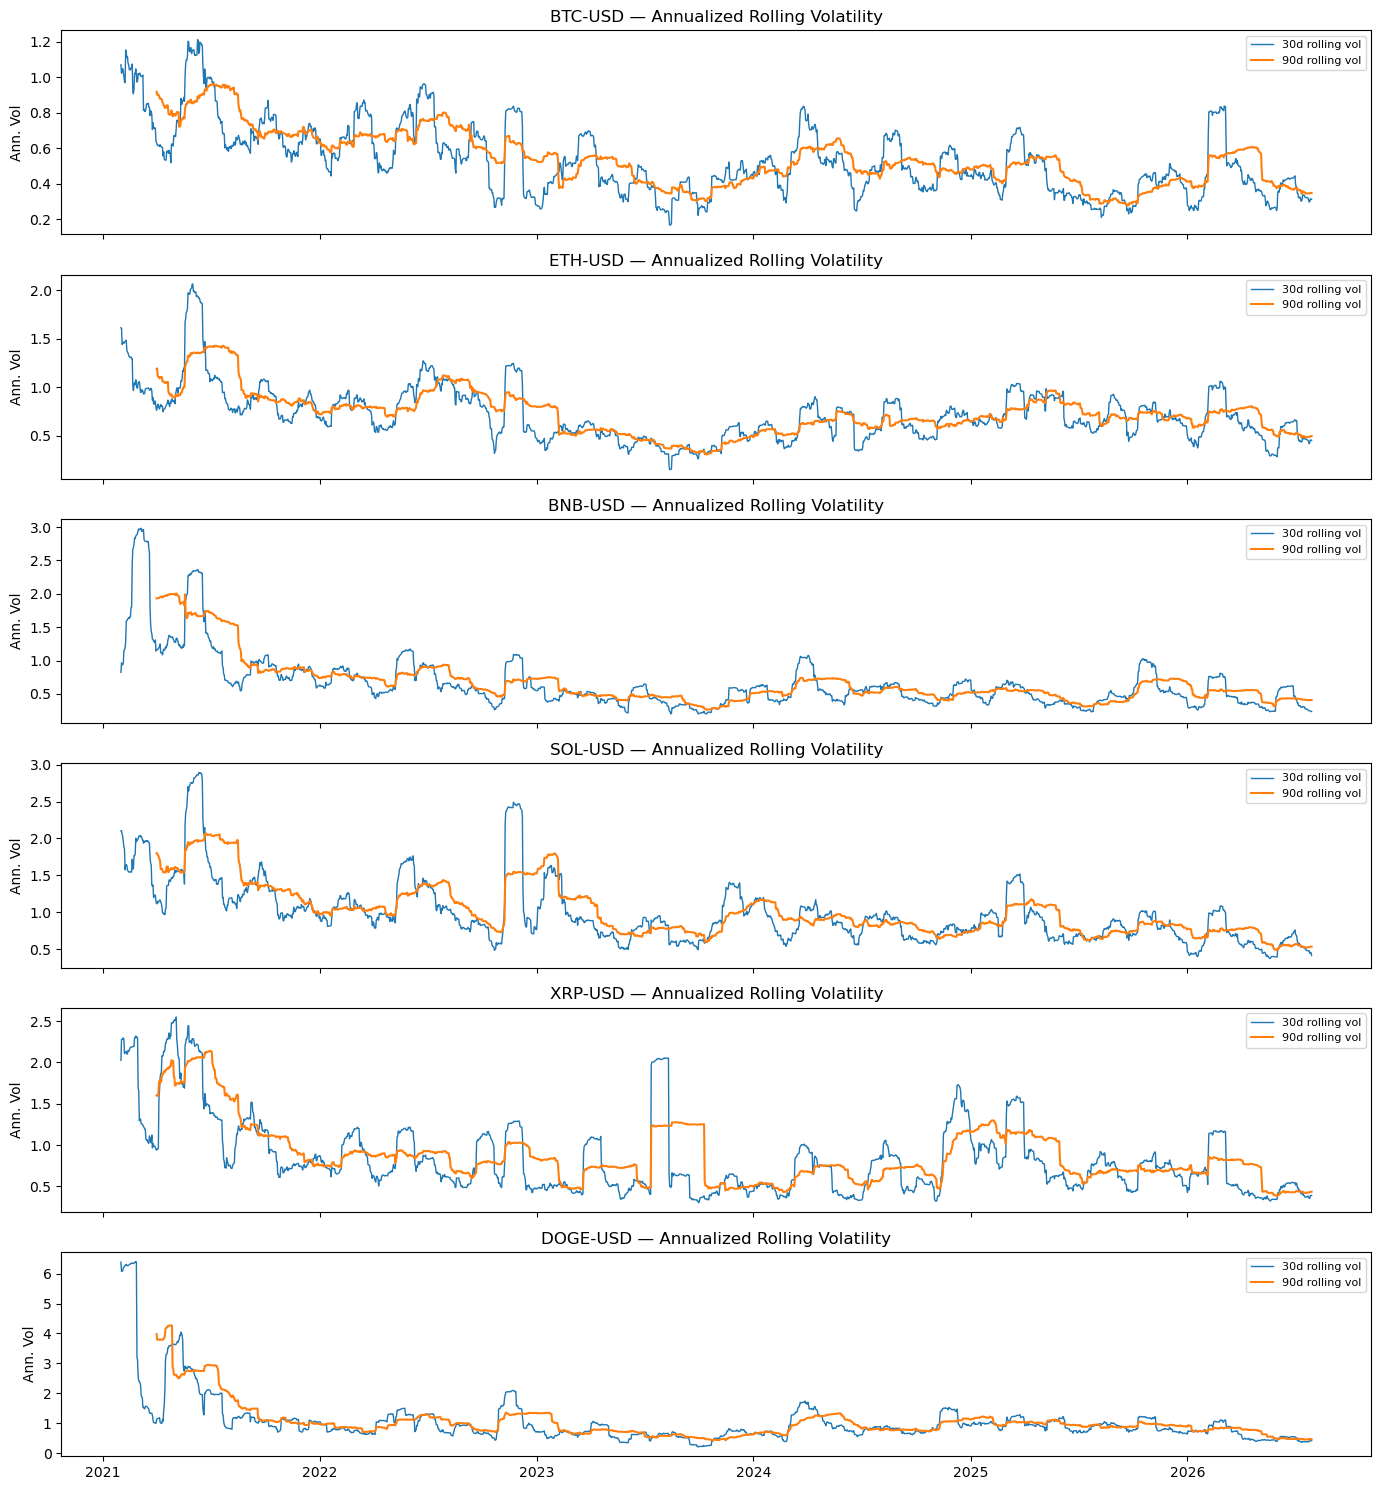

In [16]:
fig, axes = plt.subplots(len(prices.columns), 1, figsize=(14, 2.5 * len(prices.columns)), sharex=True)

for i, asset in enumerate(log_returns.columns):
    axes[i].plot(rolling_vol_30.index, rolling_vol_30[asset], label='30d rolling vol', linewidth=1)
    axes[i].plot(rolling_vol_90.index, rolling_vol_90[asset], label='90d rolling vol', linewidth=1.5)
    axes[i].set_title(f"{asset} — Annualized Rolling Volatility")
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel("Ann. Vol")

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/rolling_volatility.png", dpi=150)
plt.show()

In [17]:
vol_clustering_results = []

for asset in log_returns.columns:
    vol_30 = rolling_vol_30[asset].dropna()
    autocorr_lag1 = vol_30.autocorr(lag=1)
    vol_min, vol_max = vol_30.min(), vol_30.max()
    vol_clustering_results.append({
        "asset": asset,
        "vol_30d_autocorr_lag1": autocorr_lag1,
        "vol_30d_min": vol_min,
        "vol_30d_max": vol_max,
        "vol_range_ratio": vol_max / vol_min,
    })

vol_clustering_table = pd.DataFrame(vol_clustering_results).set_index("asset")
print(vol_clustering_table.round(3))

          vol_30d_autocorr_lag1  vol_30d_min  vol_30d_max  vol_range_ratio
asset                                                                     
BTC-USD                   0.990        0.168        1.212            7.236
ETH-USD                   0.990        0.150        2.062           13.770
BNB-USD                   0.994        0.199        2.981           14.954
SOL-USD                   0.991        0.376        2.892            7.687
XRP-USD                   0.988        0.304        2.550            8.397
DOGE-USD                  0.993        0.202        6.409           31.715


In [18]:
def underwater_curve(price_series):
    cumulative_max = price_series.cummax()
    return price_series / cumulative_max - 1


def pct_time_underwater(price_series, threshold=-0.01):
    uw = underwater_curve(price_series)
    return (uw < threshold).mean()

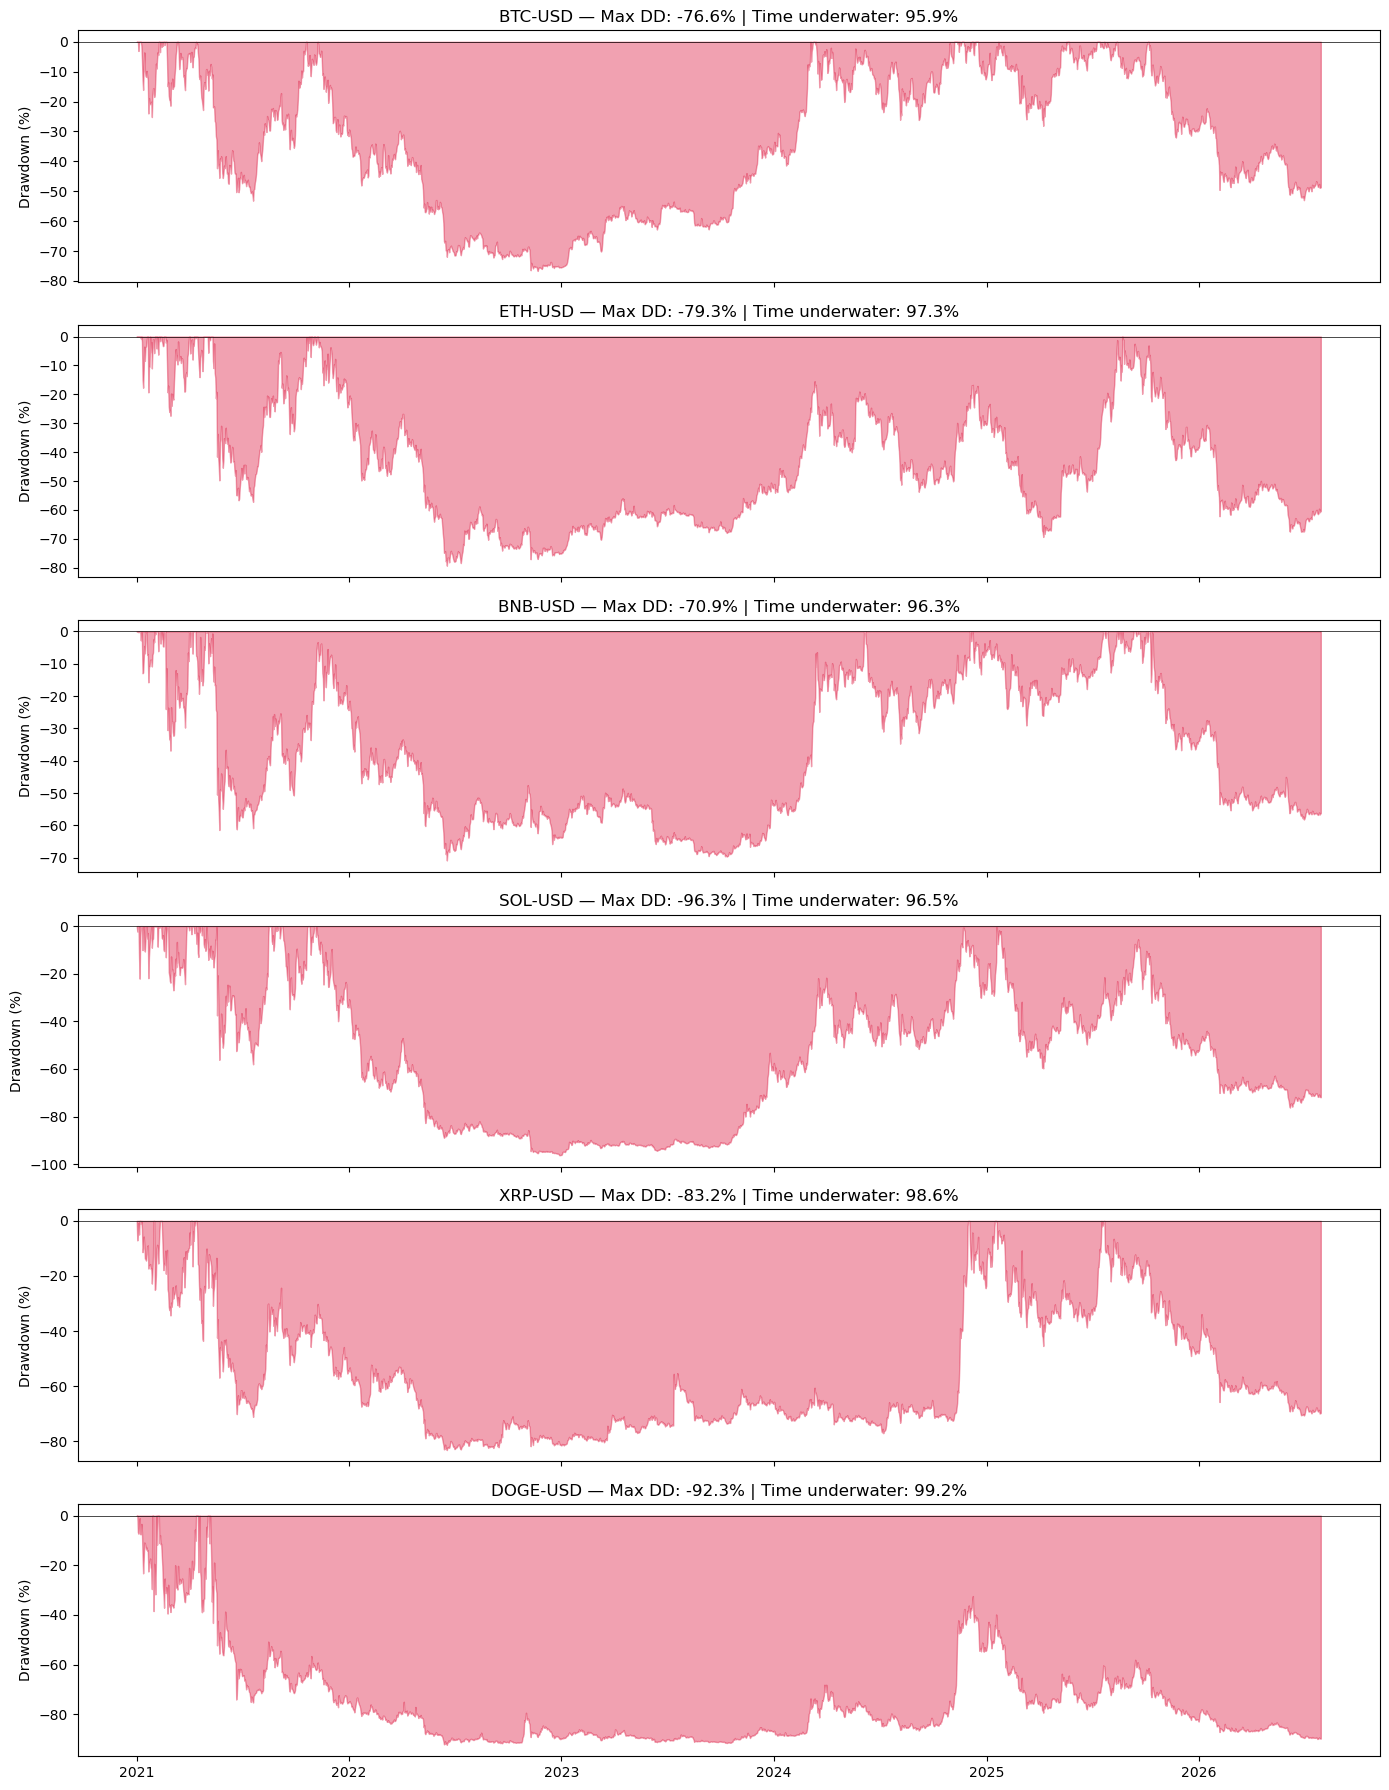

          max_drawdown  pct_time_underwater
asset                                      
BTC-USD         -0.766                0.959
ETH-USD         -0.793                0.973
BNB-USD         -0.709                0.963
SOL-USD         -0.963                0.965
XRP-USD         -0.832                0.986
DOGE-USD        -0.923                0.992


In [19]:
underwater_results = []

fig, axes = plt.subplots(len(prices.columns), 1, figsize=(14, 3 * len(prices.columns)), sharex=True)

for i, asset in enumerate(prices.columns):
    price_series = prices[asset].dropna()
    uw = underwater_curve(price_series)
    mdd = uw.min()
    pct_uw = pct_time_underwater(price_series)

    axes[i].fill_between(uw.index, uw.values * 100, 0, color='crimson', alpha=0.4)
    axes[i].set_title(f"{asset} — Max DD: {mdd:.1%} | Time underwater: {pct_uw:.1%}")
    axes[i].set_ylabel("Drawdown (%)")
    axes[i].axhline(0, color='black', linewidth=0.5)

    underwater_results.append({
        "asset": asset,
        "max_drawdown": mdd,
        "pct_time_underwater": pct_uw,
    })

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/underwater_curves.png", dpi=150)
plt.show()

underwater_table = pd.DataFrame(underwater_results).set_index("asset")
underwater_table.to_csv(f"{DATA_DIR}/underwater_metrics.csv")
print(underwater_table.round(3))

In [20]:
# Peaks
for asset in prices.columns:
    price_series = prices[asset].dropna()
    peak_date = price_series.idxmax()
    peak_value = price_series.max()

    # search for the first after peak day, when the price is same or higher level
    after_peak = price_series[price_series.index > peak_date]
    recovery = after_peak[after_peak >= peak_value]

    if len(recovery) > 0:
        recovery_date = recovery.index[0]
        days_to_recover = (recovery_date - peak_date).days
        print(f"{asset}: peak on {peak_date.date()}, recovered on {recovery_date.date()} ({days_to_recover} days)")
    else:
        print(f"{asset}: peak on {peak_date.date()}, NOT YET recovered as of {price_series.index[-1].date()}")

BTC-USD: peak on 2025-10-06, NOT YET recovered as of 2026-07-29
ETH-USD: peak on 2025-08-22, NOT YET recovered as of 2026-07-29
BNB-USD: peak on 2025-10-08, NOT YET recovered as of 2026-07-29
SOL-USD: peak on 2025-01-18, NOT YET recovered as of 2026-07-29
XRP-USD: peak on 2025-07-22, NOT YET recovered as of 2026-07-29
DOGE-USD: peak on 2021-05-07, NOT YET recovered as of 2026-07-29


# Part 5. Conclusions 

# Drawdown Analysis 
# All six assets spent between 95.9% (BTC) and 99.2% (DOGE) as of the January 2021 – present period below their historical all-time high. The sample genuinely captures the full cycle: the run-up to the November 2021 peak, the 2022 crash, and the subsequent recovery.

# The high underwater percentage instead reflects a structural feature of how drawdowns work: reaching a new all-time high is a single instantaneous event, while the recovery process that follows a major drawdown can take years. Even though most assets in this portfolio still delivered strong annualized returns over the full period (e.g. SOL: +93.8%/year), the majority of that period was spent climbing back toward the 2021 peak. This is a classic asymmetry in drawdown-based metrics: an asset can be a strong long-term investment overall while still spending the vast majority of its lifetime below its own historical high.

# BNB shows the mildest drawdown profile (-70.9% max drawdown, 96.3% time underwater), while SOL's -96.3% max drawdown is the most severe in the portfolio.


# Rolling Volatility & Clustering

# Lag-1 autocorrelation of 30-day rolling volatility is extremely high across all six assets (0.988–0.994), providing statistical confirmation that volatility clustering is a strong, systematic feature of crypto markets: turbulent periods persist and calm periods persist rather than volatility behaving as day-to-day random noise.

# The practical magnitude of this regime-switching is best captured by the volatility range ratio: DOGE's 30-day annualized volatility swung between 20.2% (a range comparable to a blue-chip stock) and 640.9% (a 31.7x range) over the sample period. BNB and ETH show similarly extreme ranges (15.0x and 13.8x respectively).

# Key takeaway: a single static volatility figure — the kind used in the annualized_vol column or a naive parametric VaR — assumes a constant risk regime that simply does not exist in crypto markets. A risk manager relying on a single historical volatility estimate to set VaR limits would be dangerously miscalibrated during a fresh volatility spike, since realized volatility can shift by an order of magnitude within a matter of months. This is the direct motivation for using rolling, time-varying risk estimates (e.g. a 90-day rolling VaR, shown in the summary chart) rather than a single fixed number for ongoing portfolio monitoring.

# 6.Correlation Analysis: Static vs Crisis-Period Correlation

In [ ]:
import seaborn as sns
static_corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(static_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=0, vmax=1, ax=ax)
ax.set_title("Static Correlation Matrix (full sample period)")
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/correlation_static.png", dpi=150)
plt.show()

static_corr.to_csv(f"{DATA_DIR}/correlation_static.csv")

In [ ]:
# Market-wide volatility proxy: average 30-day rolling volatility across all assets
market_vol_proxy = rolling_vol_30.mean(axis=1)

# Define stress regime as top 10% of days by market-wide volatility
stress_threshold = market_vol_proxy.quantile(0.90)
stress_days = market_vol_proxy > stress_threshold
calm_days = ~stress_days

# Align with log_returns index (drop NaN rows from rolling window warm-up)
valid_index = market_vol_proxy.dropna().index
stress_days = stress_days.reindex(valid_index).fillna(False)
calm_days = calm_days.reindex(valid_index).fillna(False)

returns_aligned = log_returns.loc[valid_index]

corr_calm = returns_aligned[calm_days].corr()
corr_stress = returns_aligned[stress_days].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_calm, annot=True, fmt=".2f", cmap='coolwarm', vmin=0, vmax=1, ax=axes[0])
axes[0].set_title(f"Calm periods (bottom 90% volatility)\nn={calm_days.sum()} days")

sns.heatmap(corr_stress, annot=True, fmt=".2f", cmap='coolwarm', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Stress periods (top 10% volatility)\nn={stress_days.sum()} days")

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/correlation_calm_vs_stress.png", dpi=150)
plt.show()

In [ ]:
# Quantify the "diversification disappears in crisis" effect
n_assets = len(log_returns.columns)
upper_triangle_idx = np.triu_indices(n_assets, k=1)

avg_corr_calm = corr_calm.values[upper_triangle_idx].mean()
avg_corr_stress = corr_stress.values[upper_triangle_idx].mean()
avg_corr_full = static_corr.values[upper_triangle_idx].mean()

correlation_regime_summary = pd.DataFrame({
    "regime": ["Full period", "Calm periods", "Stress periods"],
    "avg_pairwise_correlation": [avg_corr_full, avg_corr_calm, avg_corr_stress],
})
correlation_regime_summary["increase_vs_calm_pct"] = (
    (correlation_regime_summary["avg_pairwise_correlation"] - avg_corr_calm) / avg_corr_calm * 100
)

correlation_regime_summary.to_csv(f"{DATA_DIR}/correlation_regime_summary.csv", index=False)
print(correlation_regime_summary.round(3))

In [ ]:
# Define stress periods using specific known crypto crisis windows,
# rather than a volatility percentile proxy. This avoids contamination
# from idiosyncratic single-asset noise (like DOGE) and isolates genuine
# market-wide systemic events.

known_crisis_windows = [
    ("2022-05-07", "2022-05-14"),   # Terra/Luna collapse
    ("2022-06-10", "2022-06-20"),   # Celsius / broad crypto credit crisis
    ("2022-11-06", "2022-11-15"),   # FTX collapse
]

crisis_mask = pd.Series(False, index=log_returns.index)
for start, end in known_crisis_windows:
    crisis_mask |= (log_returns.index >= start) & (log_returns.index <= end)

calm_mask_events = ~crisis_mask

corr_crisis_events = log_returns[crisis_mask].corr()
corr_calm_events = log_returns[calm_mask_events].corr()

avg_corr_crisis_events = corr_crisis_events.values[np.triu_indices(6, k=1)].mean()
avg_corr_calm_events = corr_calm_events.values[np.triu_indices(6, k=1)].mean()

print(f"Known crisis windows — avg correlation: {avg_corr_crisis_events:.3f} (n={crisis_mask.sum()} days)")
print(f"Non-crisis days — avg correlation: {avg_corr_calm_events:.3f} (n={calm_mask_events.sum()} days)")
print(f"Change: {(avg_corr_crisis_events - avg_corr_calm_events) / avg_corr_calm_events * 100:.1f}%")

# Part 6. Conclusions. 
# The choice of how "crisis" is defined turns out to matter enormously for this analysis. Using a naive volatility-percentile proxy (top 10% of average portfolio volatility), average pairwise correlation appeared to decrease during stress periods (0.659 → 0.554), contradicting the classic "correlation converges in a crisis" thesis. 

# Digging into the pairwise data revealed this was driven entirely by DOGE, whose extreme, idiosyncratic meme-driven volatility spikes (vol range ratio: 31.7x, the highest in the portfolio) frequently pushed days into the "stress" bucket without any genuine market-wide shock occurring — contaminating the signal.

# Re-running the analysis using specific, known systemic crisis windows (the May 2022 Terra/Luna collapse, the November 2022 FTX collapse, 29 trading days total) tells a completely different and far more convincing story: average pairwise correlation rises from 0.559 on normal days to 0.867 during these crisis windows — a 55% increase. At 0.867, the six assets move almost as a single instrument during genuine systemic shocks, compared to meaningfully more independent behavior(0.559) in normal market conditions.

# This is the central risk management insight of this project: a crypto portfolio that appears reasonably diversified day-to-day can lose the vast majority of that diversification benefit within days, precisely when protection from correlated losses matters most. It also carries an important methodological lesson: naive statistical proxies for "crisis"(like a volatility percentile) can be misleading when a single high-noise asset dominates the proxy signal. Anchoring stress-period analysis to known, verifiable systemic events — rather than a generic statistical threshold — produced a far cleaner and more decision-useful result here.

# 7. Portfolio-Level VaR: Combining Assets into a Single Portfolio Return Series

In [ ]:
# Define portfolio weights.
portfolio_weights = pd.Series({
    "BTC-USD": 0.40,
    "ETH-USD": 0.25,
    "BNB-USD": 0.10,
    "SOL-USD": 0.10,
    "XRP-USD": 0.10,
    "DOGE-USD": 0.05,
}, index=log_returns.columns)

assert np.isclose(portfolio_weights.sum(), 1.0), "Weights must sum to 1"

# Portfolio daily log returns
portfolio_returns = (log_returns * portfolio_weights).sum(axis=1)
portfolio_returns.name = "portfolio"

In [ ]:
# Now just reuse the SAME three functions we already built and validated in the individual-asset VaR section — no need for anything new.

portfolio_var_results = {}
portfolio_cvar_results = {}

for cl in CONFIDENCE_LEVELS:
    portfolio_var_results[cl] = {
        "historical": historical_var(portfolio_returns, cl),
        "parametric": parametric_var(portfolio_returns, cl),
        "monte_carlo": monte_carlo_var(portfolio_returns, cl),
    }
    portfolio_cvar_results[cl] = {
        "historical": historical_cvar(portfolio_returns, cl),
        "parametric": parametric_cvar(portfolio_returns, cl),
        "monte_carlo": monte_carlo_cvar(portfolio_returns, cl),
    }

portfolio_var_table = pd.DataFrame(portfolio_var_results)
portfolio_cvar_table = pd.DataFrame(portfolio_cvar_results)

portfolio_var_table.to_csv(f"{DATA_DIR}/portfolio_var.csv")
portfolio_cvar_table.to_csv(f"{DATA_DIR}/portfolio_cvar.csv")

print("Portfolio VaR:\n", portfolio_var_table.round(4))
print("\nPortfolio CVaR:\n", portfolio_cvar_table.round(4))

In [ ]:
# Backtest 
def var_breach_test(returns, var_value, confidence):
    breaches = (returns < -var_value).sum()
    expected_breaches = len(returns) * (1 - confidence)
    return breaches, round(expected_breaches, 1)

breach_results = []
for method in ["historical", "parametric", "monte_carlo"]:
    for cl in CONFIDENCE_LEVELS:
        var_value = portfolio_var_results[cl][method]
        breaches, expected = var_breach_test(portfolio_returns, var_value, cl)
        breach_results.append({
            "method": method,
            "confidence": cl,
            "actual_breaches": breaches,
            "expected_breaches": expected,
            "breach_ratio": round(breaches / expected, 2),
        })

breach_table = pd.DataFrame(breach_results)
breach_table.to_csv(f"{DATA_DIR}/var_breach_backtest.csv", index=False)
print(breach_table)

# Part 7. Conclusions.
# Portfolio-level results confirm every pattern observed at the individual-asset level, and the backtest provides the strongest, most decision-relevant evidence in the entire analysis.

# At 95% confidence, parametric VaR (5.56%) is again slightly higher than historical (5.42%) and Monte Carlo (4.99%) — the familiar "inflated sigma" effect. At 99% confidence, the pattern sharply reverses: parametric VaR (7.89%) sits well below historical (10.15%) and Monte Carlo (9.35%).

# Diversification also provided less protection than a naive six-asset portfolio might suggest: portfolio VaR-99 (10.15% historical) is actually higher than BTC's own individual VaR-99 (8.58%), despite BTC carrying the largest single weight (40%) in the portfolio. This is a direct consequence of the high cross-asset correlation established earlier (0.559 in calm markets, rising to 0.867 during genuine systemic crises like the Terra/Luna and FTX collapses) — this portfolio behaves, in practice, much closer to a single concentrated crypto bet than a well-diversified allocation.

# The backtest removes any ambiguity about which VaR method performs best. Across the full sample, parametric VaR at 99% confidence produced a breach ratio of 1.67 — realized losses exceeded the VaR threshold 67% more often than the model itself predicted. Historical VaR (1.03) and Monte Carlo VaR (1.27) were both far closer to correct calibration at the same confidence level.

# Key takeaway of the Project itself.

# This is the single most important, decision-relevant finding of the project: a risk manager relying on parametric (normal-distribution) VaR at the 99% confidence level would have been meaningfully under-provisioned for tail risk in this portfolio as a measurable, repeated failure verified against the actual historical record. For crypto portfolios, this makes a strong case for using historical simulation or Monte Carlo with fat-tailed distributions as the primary risk measure, with parametric VaR reserved at most as a quick sanity check rather than a decision-making tool.

# Final Summary Chart: Portfolio Performance, Risk, and VaR Breaches

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- Panel 1: cumulative portfolio return ---
cumulative_portfolio_value = np.exp(portfolio_returns.cumsum())
axes[0].plot(cumulative_portfolio_value.index, cumulative_portfolio_value.values,
             color='tab:blue', linewidth=1.2)
axes[0].set_title("Portfolio Cumulative Return (Growth of $1, Jan 2021 – present)", fontsize=12)
axes[0].set_ylabel("Portfolio Value")
axes[0].grid(alpha=0.3)

# --- Panel 2: underwater curve ---
portfolio_underwater = underwater_curve(cumulative_portfolio_value)
axes[1].fill_between(portfolio_underwater.index, portfolio_underwater.values * 100, 0,
                      color='crimson', alpha=0.4)
axes[1].plot(portfolio_underwater.index, portfolio_underwater.values * 100,
             color='darkred', linewidth=0.8)
axes[1].set_title(f"Portfolio Underwater Curve (Max Drawdown: {portfolio_underwater.min():.1%})",
                   fontsize=12)
axes[1].set_ylabel("Drawdown (%)")
axes[1].grid(alpha=0.3)

# --- Panel 3: rolling 90d historical VaR vs actual daily returns, with breach markers ---
rolling_var_95 = portfolio_returns.rolling(90).apply(lambda x: historical_var(x, 0.95))
breaches_mask = portfolio_returns < -rolling_var_95

axes[2].plot(portfolio_returns.index, portfolio_returns.values * 100,
             alpha=0.4, linewidth=0.6, color='gray', label='Daily portfolio return')
axes[2].plot(rolling_var_95.index, -rolling_var_95.values * 100,
             color='red', linewidth=1.2, label='90d rolling historical VaR (95%)')
axes[2].scatter(portfolio_returns.index[breaches_mask],
                 portfolio_returns.values[breaches_mask] * 100,
                 color='darkred', s=18, zorder=5, label=f'VaR breach (n={breaches_mask.sum()})')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title("Daily Returns vs Rolling VaR — Breach Points Highlighted", fontsize=12)
axes[2].set_ylabel("Return (%)")
axes[2].legend(fontsize=9, loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/summary_chart.png", dpi=150, bbox_inches='tight')
plt.show()